In [ ]:
import pandas as pd
import ast
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
#read data
#upload news and price data
news = pd.read_csv('data/news/all_news.csv', date_format='pubDate')
price = pd.read_csv('data/all_zec.csv')
print('before dedup', news.shape, price.shape)
#normalize timestamps
price['timestamp'] = pd.to_datetime(price['timestamp'], utc=True)
news['pubDate'] = pd.to_datetime(news['pubDate'], utc=True)
news['fetched_at'] = pd.to_datetime(news['fetched_at'], utc=True)
news = news.drop_duplicates(subset='article_id')
news = news.sort_values(by = 'pubDate').reset_index(drop=True)
price = price.drop_duplicates(subset='timestamp')
price = price.set_index('timestamp').sort_index()
print('after_dedup (news df already was dedupped)', news.shape, price.shape)

before dedup (7326, 23) (23446, 4)
after_dedup (news df already was dedupped) (7326, 23) (18160, 3)


Modeling objective: to predict the Delta in price over the following 5,10,15,30 min after a piece of news has been released, ie. does news at time t move zec prices shortly after? 

In [ ]:
#this function returns the % change in price right before a piece of news and horizon minutes later
def get_price_change(price_df, t, horizon):
    p0= price.loc[:t].iloc[-1]['price']
    p1=price.loc[t+pd.Timedelta(horizon['delta'],horizon['units']):].iloc[0]['price']
    return (p0-p1)/p0

In [ ]:
#get news after first recorded price
news= news[news['pubDate']> price.index[0]]
#define deltas for % change 5m, 30m, 1h, 3h, 6h, 12h later
d = [{'delta':5, 'units':'m'},
     {'delta':30, 'units':'m'},
     {'delta':60, 'units':'m'},
     {'delta':180, 'units':'m'},
     {'delta':360, 'units':'m'},
     {'delta':720, 'units':'m'}]

#apply to news df to store all info
for x in d:
    col = str(x['delta'])
    news[col] = news.apply(lambda row: get_price_change(price,row['pubDate'],x),axis=1)


In [ ]:
#feature engineering
#do not use 'content' bc it is only complete in paid download
news['title_word_count'] = news['title'].str.split().str.len()
news['has_zec'] = news['coin'].str.contains('ZEC', regex=False)
news['num_coins_mentioned'] = news['coin'].apply(
    lambda x: len(ast.literal_eval(x)) if isinstance(x, str) else 0
)


In [ ]:
news['has_zec'].value_counts()

has_zec
True     1210
False     999
Name: count, dtype: int64

## SANITY CHECKS

In [ ]:

# --- REQUIRED PREP (run once) ---
price = price.copy()
news = news.copy()

# price: ensure DatetimeIndex UTC + sorted
if 'timestamp' in price.columns:
    price['timestamp'] = pd.to_datetime(price['timestamp'], utc=True)
    price = price.set_index('timestamp')
price.index = pd.to_datetime(price.index, utc=True)
price = price.sort_index()

# news: ensure pubDate UTC
news['pubDate'] = pd.to_datetime(news['pubDate'], utc=True)
news = news.sort_values('pubDate')

# --- HELPERS ---
def _nearest_time_index(idx: pd.DatetimeIndex, t: pd.Timestamp, side: str):
    # side='before' gives last idx <= t; side='after' gives first idx >= t
    pos = idx.searchsorted(t, side='right' if side == 'before' else 'left')
    if side == 'before':
        return pos - 1
    return pos

def forward_log_return(price_df: pd.DataFrame, t: pd.Timestamp, horizon: pd.Timedelta) -> float:
    idx = price_df.index
    i0 = _nearest_time_index(idx, t, side='before')
    i1 = _nearest_time_index(idx, t + horizon, side='after')
    if i0 < 0 or i1 >= len(idx):
        return np.nan
    p0 = price_df.iloc[i0]['price']
    p1 = price_df.iloc[i1]['price']
    return float(np.log(p1 / p0))

def add_text_features(news_df: pd.DataFrame) -> pd.DataFrame:
    df = news_df.copy()
    # robust word count: prefer description; fallback to title
    text = df['description'].fillna(df.get('title')).fillna('')
    df['word_count'] = text.astype(str).str.split().str.len()
    df['title_word_count'] = df['title'].fillna('').astype(str).str.split().str.len()
    df['description_word_count'] = df['description'].fillna('').astype(str).str.split().str.len()
    # coin may be list or string; normalize
    def _has_zec(x):
        if isinstance(x, list):
            return 'ZEC' in x
        s = '' if pd.isna(x) else str(x)
        return ('ZEC' in s) or ('zcash' in s.lower())
    df['has_zec'] = df['coin'].apply(_has_zec)
    return df

news = add_text_features(news)

# forward returns for horizons you care about
H5  = pd.Timedelta(minutes=5)
H30 = pd.Timedelta(minutes=30)
news['ret_5m'] = news['pubDate'].apply(lambda t: forward_log_return(price, t, H5))
news['ret_30m'] = news['pubDate'].apply(lambda t: forward_log_return(price, t, H30))
news['abs_ret_30m'] = news['ret_30m'].abs()


In [ ]:
news['content']

4196                                                  NaN
4197    North Korean state-backed hackers, the Lazarus...
4198    Bitcoin crash: Crypto market saw a sudden sell...
4199    - - Volume: - Bitcoin has plunged more than 5 ...
4200    CoinShares has withdrawn its US ETFs for XRP, ...
                              ...                        
7320                         ONLY AVAILABLE IN PAID PLANS
7321                         ONLY AVAILABLE IN PAID PLANS
7322                         ONLY AVAILABLE IN PAID PLANS
7323                         ONLY AVAILABLE IN PAID PLANS
7324                         ONLY AVAILABLE IN PAID PLANS
Name: content, Length: 3129, dtype: object

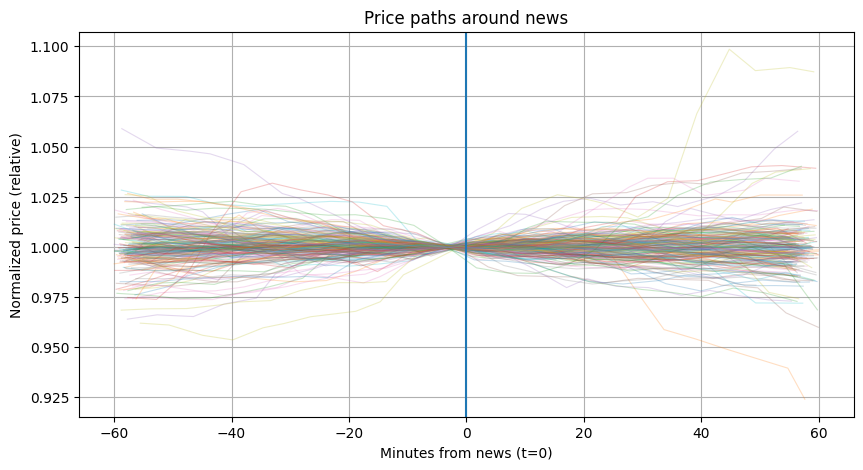

In [ ]:
# =========================
# STEP 1: Price paths around news (event plots)
# =========================
def plot_event_paths(price_df, event_times, window=pd.Timedelta('60min'), max_events=200):
    idx = price_df.index
    event_times = pd.to_datetime(pd.Series(event_times), utc=True).dropna().sort_values()
    if len(event_times) > max_events:
        event_times = event_times.sample(max_events, random_state=0).sort_values()

    plt.figure(figsize=(10,5))
    for t in event_times:
        start = t - window
        end = t + window
        # slice and align relative minutes
        seg = price_df.loc[start:end, 'price']
        if len(seg) < 2:
            continue

        #######Normalize to t of news
        # price at (or just before) news time
        pre = price_df.loc[:t, 'price']
        if len(pre) == 0:
            continue
        p_t = pre.iloc[-1]

        rel_min = (seg.index - t).total_seconds() / 60.0
        norm = seg / p_t 

        ##### normalize to 60 min prior to news
#       rel_min = (seg.index - t).total_seconds() / 60.0
#       norm = seg / seg.iloc[0]  # normalize to 1 at start of window slice
        ###########
        plt.plot(rel_min, norm.values, linewidth=0.8, alpha=0.25)
    plt.axvline(0, linewidth=1.5)
    plt.xlabel('Minutes from news (t=0)')
    plt.ylabel('Normalized price (relative)')
    plt.title('Price paths around news')
    plt.grid(True)
    plt.show()

def filter_events_min_gap(event_times, min_gap=pd.Timedelta("60min")):
    event_times = pd.to_datetime(pd.Series(event_times), utc=True).dropna().sort_values()
    kept = []
    last = None
    for t in event_times:
        if last is None or (t - last) >= min_gap:
            kept.append(t)
            last = t
    return pd.Series(kept)

events_sparse = filter_events_min_gap(news['pubDate'], pd.Timedelta("60min"))
plot_event_paths(price, events_sparse, window=pd.Timedelta("60min"), max_events=200)

#plot_event_paths(price, news['pubDate'], window=pd.Timedelta('60min'), max_events=200)


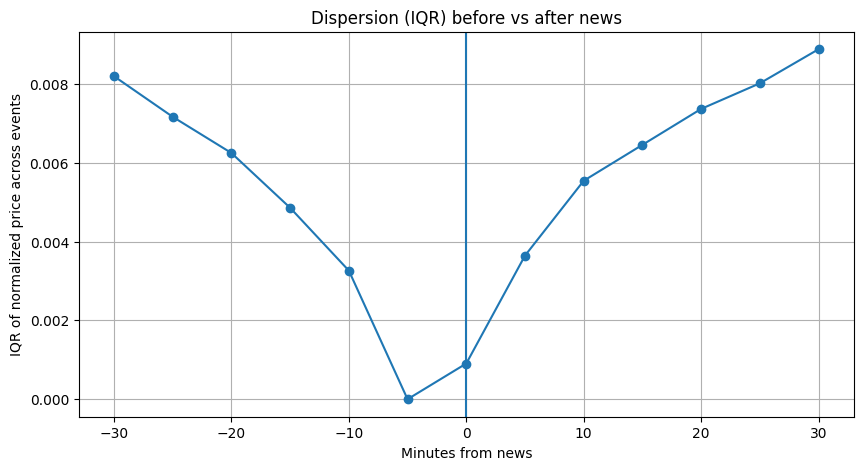

In [ ]:
def event_dispersion_curve(price_df, event_times, window=pd.Timedelta("30min"), freq="5min"):
    event_times = pd.to_datetime(pd.Series(event_times), utc=True).dropna().sort_values()

    rel_grid = pd.timedelta_range(-window, window, freq=freq)
    rel_min = rel_grid.total_seconds() / 60.0

    paths = []
    for t in event_times:
        # anchor price at/just before t
        pre = price_df.loc[:t, 'price']
        if len(pre) == 0:
            continue
        p_t = pre.iloc[-1]

        # sample prices on the relative grid (nearest after each timestamp)
        ts = t + rel_grid
        seg = price_df.reindex(ts, method="nearest")['price'] / p_t

        if seg.isna().any():
            continue
        paths.append(seg.values)

    X = np.vstack(paths)  # shape: (n_events, n_timepoints)

    # robust dispersion: IQR across events at each timepoint
    q75 = np.quantile(X, 0.75, axis=0)
    q25 = np.quantile(X, 0.25, axis=0)
    iqr = q75 - q25

    return rel_min, iqr
# fix duplicates in price index
price = price.sort_index()
price = price[~price.index.duplicated(keep="last")]   # or keep="first"

rel_min, iqr = event_dispersion_curve(price, news['pubDate'], window=pd.Timedelta("30min"), freq="5min")

plt.figure(figsize=(10,5))
plt.plot(rel_min, iqr, marker='o')
plt.axvline(0)
plt.xlabel("Minutes from news")
plt.ylabel("IQR of normalized price across events")
plt.title("Dispersion (IQR) before vs after news")
plt.grid(True)
plt.show()


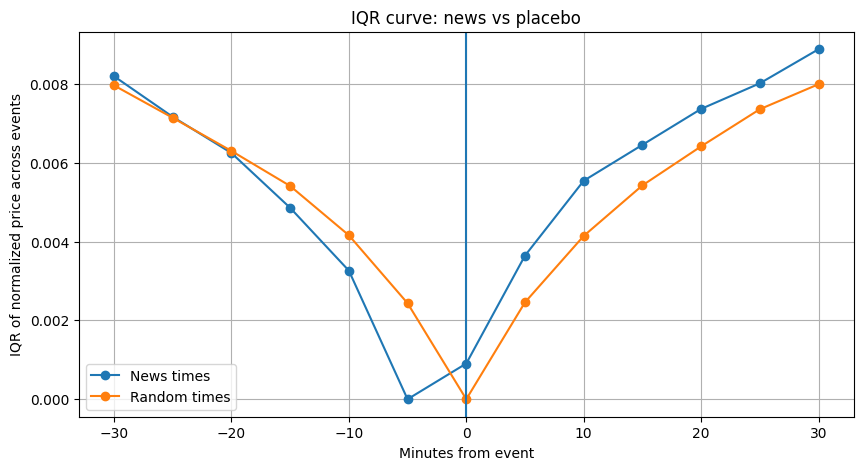

In [ ]:
def iqr_curve(price_df, event_times, window=pd.Timedelta("30min"), freq="5min"):
    event_times = pd.to_datetime(pd.Series(event_times), utc=True).dropna().sort_values()

    rel_grid = pd.timedelta_range(-window, window, freq=freq)
    rel_min = rel_grid.total_seconds() / 60.0

    paths = []
    for t in event_times:
        pre = price_df.loc[:t, 'price']
        if len(pre) == 0:
            continue
        p_t = pre.iloc[-1]

        ts = t + rel_grid
        seg = price_df.reindex(ts, method="nearest")['price'] / p_t
        if seg.isna().any():
            continue
        paths.append(seg.values)

    X = np.vstack(paths)
    iqr = np.quantile(X, 0.75, axis=0) - np.quantile(X, 0.25, axis=0)
    return rel_min, iqr

def sample_random_times_from_index(idx, n, seed=1234, start=None, end=None):
    idx = idx.sort_values()
    if start is not None: idx = idx[idx >= start]
    if end is not None:   idx = idx[idx <= end]
    rng = np.random.default_rng(seed)
    n = min(n, len(idx))
    pos = rng.choice(len(idx), size=n, replace=False)
    return pd.Series(idx.take(pos)).sort_values()

# build curves
events_news = news['pubDate'].dropna().sort_values()
events_rand = sample_random_times_from_index(
    price.index, len(events_news), seed=0,
    start=events_news.min(), end=events_news.max()
)

rel_min, iqr_news = iqr_curve(price, events_news, window=pd.Timedelta("30min"), freq="5min")
_,       iqr_rand = iqr_curve(price, events_rand, window=pd.Timedelta("30min"), freq="5min")

plt.figure(figsize=(10,5))
plt.plot(rel_min, iqr_news, marker='o', label='News times')
plt.plot(rel_min, iqr_rand, marker='o', label='Random times')
plt.axvline(0)
plt.xlabel("Minutes from event")
plt.ylabel("IQR of normalized price across events")
plt.title("IQR curve: news vs placebo")
plt.grid(True)
plt.legend()
plt.show()


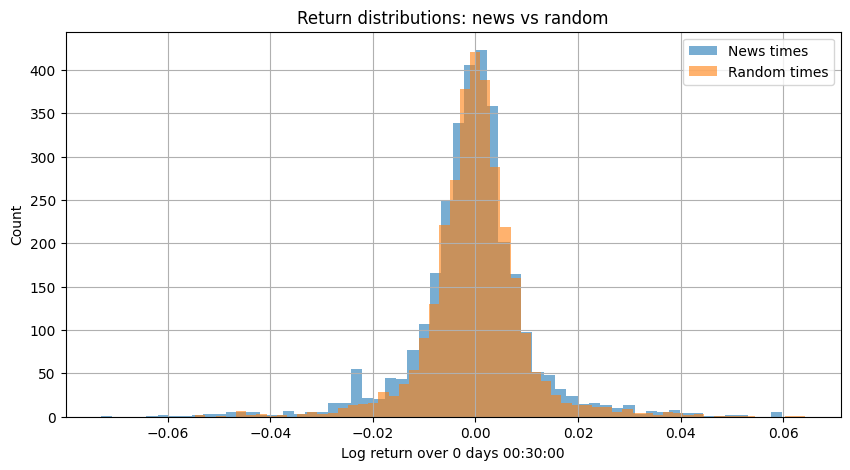

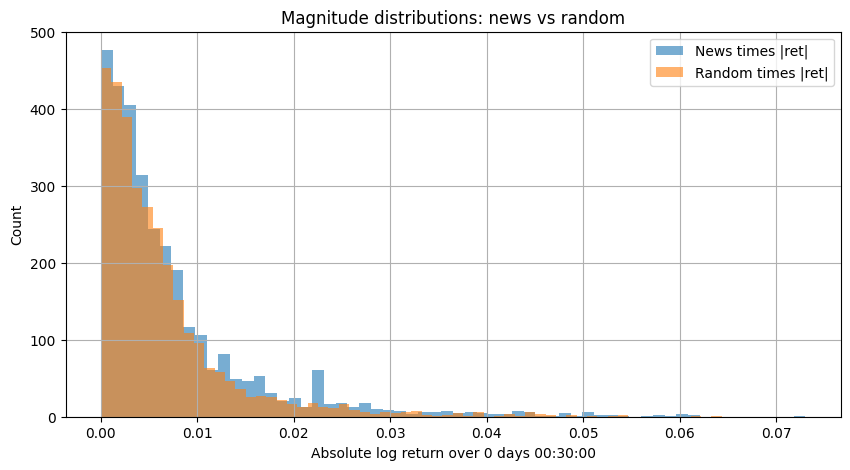

In [ ]:
# =========================
# STEP 2: Distributions of returns (with vs without news)
# =========================
def sample_random_times(price_df, n, start=None, end=None, seed=0):
    idx = price_df.index
    if start is None: start = idx.min()
    if end is None: end = idx.max()

    # ensure start/end are tz-aware in same tz as idx
    start = pd.Timestamp(start)
    end = pd.Timestamp(end)
    if idx.tz is not None:
        if start.tz is None: start = start.tz_localize(idx.tz)
        else: start = start.tz_convert(idx.tz)
        if end.tz is None: end = end.tz_localize(idx.tz)
        else: end = end.tz_convert(idx.tz)

    eligible = idx[(idx >= start) & (idx <= end)]
    rng = np.random.default_rng(seed)

    n = min(n, len(eligible))
    pos = rng.choice(len(eligible), size=n, replace=False)
    return pd.Series(eligible.take(pos)).sort_values()

def plot_return_distributions(news_df, price_df, horizon=pd.Timedelta('30min'), n_random=None, seed=0):
    ev_times = news_df['pubDate'].dropna()
    if n_random is None:
        n_random = len(ev_times)

    start = ev_times.min()
    end = ev_times.max()

    rand_times = sample_random_times(price_df, n_random, start=start, end=end, seed=seed)

    ev_ret = ev_times.apply(lambda t: forward_log_return(price_df, t, horizon))
    ev_ret = ev_times.apply(lambda t: forward_log_return(price_df, t, horizon))
    rd_ret = rand_times.apply(lambda t: forward_log_return(price_df, t, horizon))

    plt.figure(figsize=(10,5))
    plt.hist(ev_ret.dropna().values, bins=60, alpha=0.6, label='News times')
    plt.hist(rd_ret.dropna().values, bins=60, alpha=0.6, label='Random times')
    plt.xlabel(f'Log return over {horizon}')
    plt.ylabel('Count')
    plt.title('Return distributions: news vs random')
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(10,5))
    plt.hist(ev_ret.dropna().abs().values, bins=60, alpha=0.6, label='News times |ret|')
    plt.hist(rd_ret.dropna().abs().values, bins=60, alpha=0.6, label='Random times |ret|')
    plt.xlabel(f'Absolute log return over {horizon}')
    plt.ylabel('Count')
    plt.title('Magnitude distributions: news vs random')
    plt.legend()
    plt.grid(True)
    plt.show()

plot_return_distributions(news, price, horizon=pd.Timedelta('30min'), seed=0)


In [ ]:
news_abs = news['abs_ret_30m'].dropna()
rand_abs = sample_random_times(price, len(news_abs)).apply(
    lambda t: abs(forward_log_return(price, t, pd.Timedelta("30min")))
)

#print(news_abs.mean(), rand_abs.mean())
print('*** news', news_abs.quantile([0.9, 0.95]))
print('**** rand', rand_abs.quantile([0.9, 0.95]))


*** news 0.90    0.017878
0.95    0.025255
Name: abs_ret_30m, dtype: float64
**** rand 0.90    0.014351
0.95    0.020767
Name: timestamp, dtype: float64


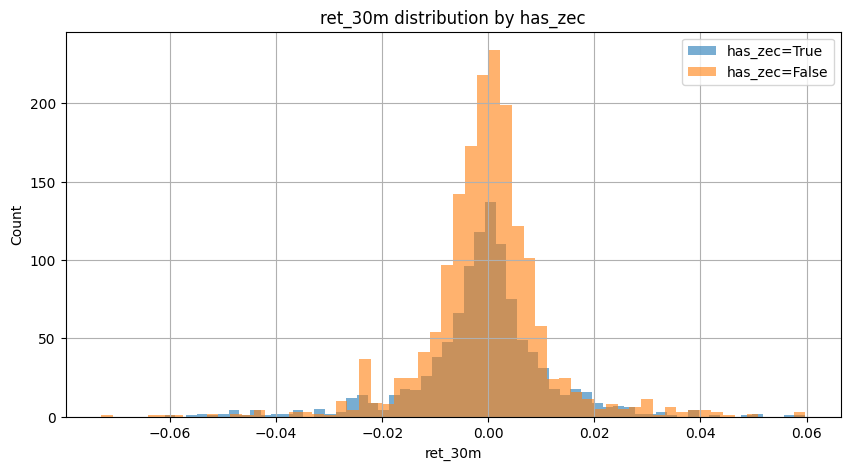

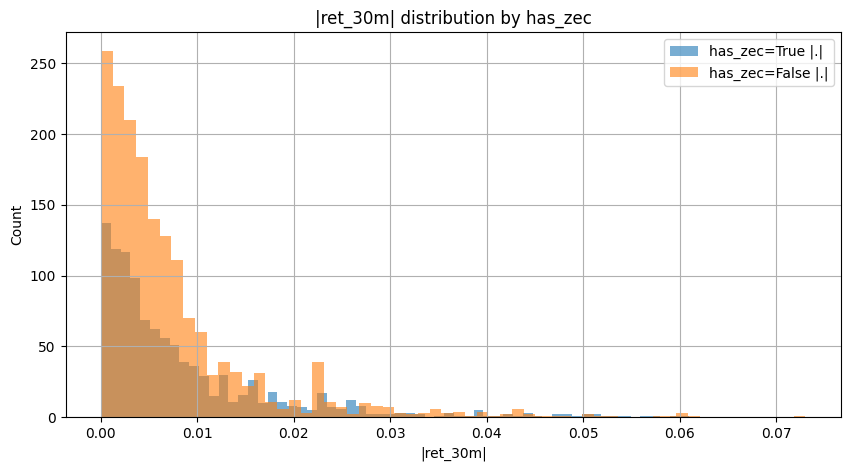

In [ ]:
# =========================
# STEP 4: ZEC-specific vs multi-coin (and quick compare plots)
# =========================
def plot_group_hist(news_df, group_col='has_zec', value_col='ret_30m'):
    a = news_df.loc[news_df[group_col] == True, value_col].dropna()
    b = news_df.loc[news_df[group_col] == False, value_col].dropna()

    plt.figure(figsize=(10,5))
    plt.hist(a.values, bins=60, alpha=0.6, label=f'{group_col}=True')
    plt.hist(b.values, bins=60, alpha=0.6, label=f'{group_col}=False')
    plt.xlabel(value_col)
    plt.ylabel('Count')
    plt.title(f'{value_col} distribution by {group_col}')
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(10,5))
    plt.hist(a.abs().values, bins=60, alpha=0.6, label=f'{group_col}=True |.|')
    plt.hist(b.abs().values, bins=60, alpha=0.6, label=f'{group_col}=False |.|')
    plt.xlabel(f'|{value_col}|')
    plt.ylabel('Count')
    plt.title(f'|{value_col}| distribution by {group_col}')
    plt.legend()
    plt.grid(True)
    plt.show()

plot_group_hist(news, group_col='has_zec', value_col='ret_30m')


In [ ]:
news[news['ret_30m'].between(-0.025, -0.021)][['article_id','sentiment','pubDate','ret_30m']].groupby([news['pubDate'].dt.date,'sentiment']).size()

pubDate     sentiment                                         
2025-12-01  negative                                               8
            positive                                               1
2025-12-02  negative                                               2
            neutral                                                1
            positive                                               1
2025-12-03  positive                                               1
2025-12-13  positive                                               1
2025-12-16  negative                                               1
            positive                                               1
2025-12-31  positive                                               1
2026-01-04  neutral                                                1
            positive                                               9
2026-01-05  negative                                               7
            neutral                     

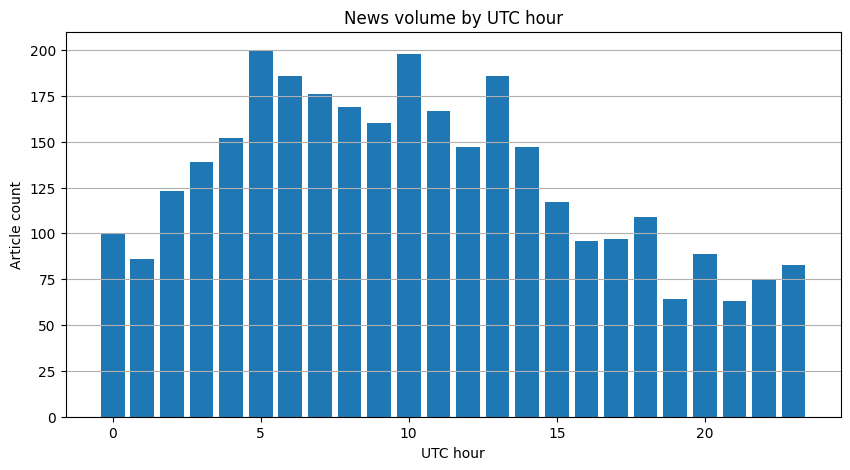

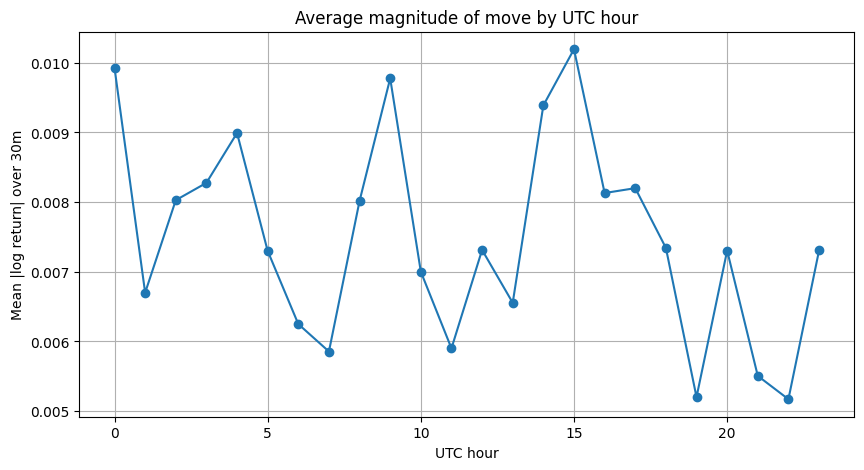

In [ ]:
# =========================
# STEP 5: Time-of-day bias (news volume + reaction by UTC hour)
# =========================
def plot_time_of_day_bias(news_df):
    df = news_df.dropna(subset=['pubDate']).copy()
    df['hour_utc'] = df['pubDate'].dt.hour

    # news volume by hour
    vol = df.groupby('hour_utc').size().reindex(range(24), fill_value=0)

    plt.figure(figsize=(10,5))
    plt.bar(vol.index, vol.values)
    plt.xlabel('UTC hour')
    plt.ylabel('Article count')
    plt.title('News volume by UTC hour')
    plt.grid(True, axis='y')
    plt.show()

    # reaction by hour (mean |ret|)
    if 'abs_ret_30m' in df.columns:
        m = df.groupby('hour_utc')['abs_ret_30m'].mean().reindex(range(24))
        plt.figure(figsize=(10,5))
        plt.plot(m.index, m.values, marker='o')
        plt.xlabel('UTC hour')
        plt.ylabel('Mean |log return| over 30m')
        plt.title('Average magnitude of move by UTC hour')
        plt.grid(True)
        plt.show()

plot_time_of_day_bias(news)


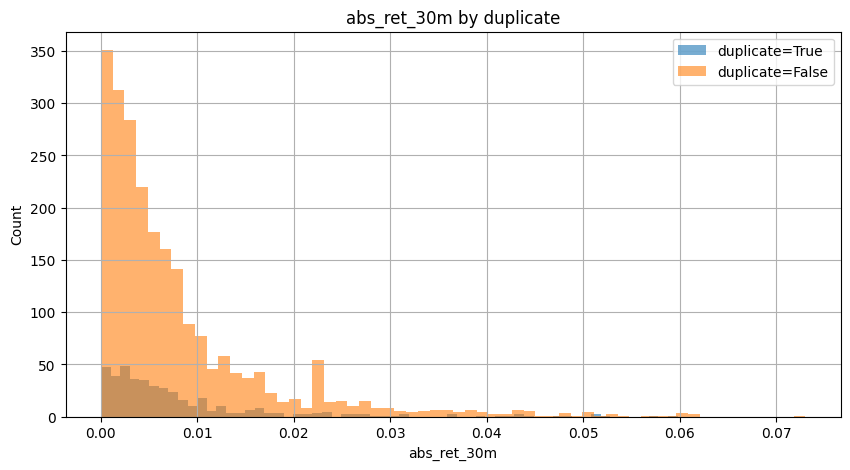

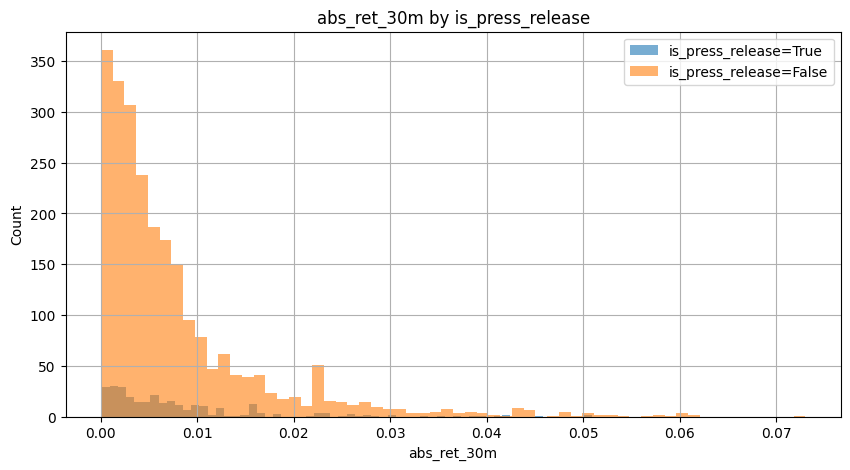

In [ ]:
# =========================
# STEP 6: Duplicate / press-release effect
# =========================
def add_press_release_flag(news_df):
    df = news_df.copy()
    # keyword/heuristics
    kw = df.get('keywords')
    text = (
        df['title'].fillna('') + ' ' +
        df.get('description', pd.Series(['']*len(df))).fillna('') + ' ' +
        df.get('content', pd.Series(['']*len(df))).fillna('')
    ).astype(str).str.lower()

    df['is_press_release'] = text.str.contains('press release') | text.str.contains('sponsored')
    # if keywords exists, include it too
    if kw is not None:
        df['is_press_release'] = df['is_press_release'] | kw.astype(str).str.lower().str.contains('press release')
    return df

news2 = add_press_release_flag(news)

def plot_binary_group_effect(df, flag_col, value_col='abs_ret_30m'):
    a = df.loc[df[flag_col] == True, value_col].dropna()
    b = df.loc[df[flag_col] == False, value_col].dropna()

    plt.figure(figsize=(10,5))
    plt.hist(a.values, bins=60, alpha=0.6, label=f'{flag_col}=True')
    plt.hist(b.values, bins=60, alpha=0.6, label=f'{flag_col}=False')
    plt.xlabel(value_col)
    plt.ylabel('Count')
    plt.title(f'{value_col} by {flag_col}')
    plt.legend()
    plt.grid(True)
    plt.show()

# duplicates (expects boolean column 'duplicate' or similar)
if 'duplicate' in news2.columns:
    plot_binary_group_effect(news2, 'duplicate', value_col='abs_ret_30m')

# press release flag
plot_binary_group_effect(news2, 'is_press_release', value_col='abs_ret_30m')


Figure out:
1. what is that spike at abs_ret_30m ~0.0225
2. what news make the dispersion on price larger

duplicate
False    5944
True     1039
Name: count, dtype: int64

In [ ]:
news['has_zec']=news['coin'].str.contains('ZEC')
# we know athat press_release =False and not duplicate
news['duplicate'].value_counts()
news['has_zec'].value_counts()

has_zec
True     1210
False     999
Name: count, dtype: int64

In [ ]:
#news visual analysis
news[~news['ret_30m'].isna()][['pubDate', 'article_id', 'title', 'description', 'creator', 'keywords', 'ai_tag', 'ret_5m', 'ret_30m']].to_csv('news_w_return.csv',index=False)

array([[<Axes: title={'center': 'sign_change'}>]], dtype=object)

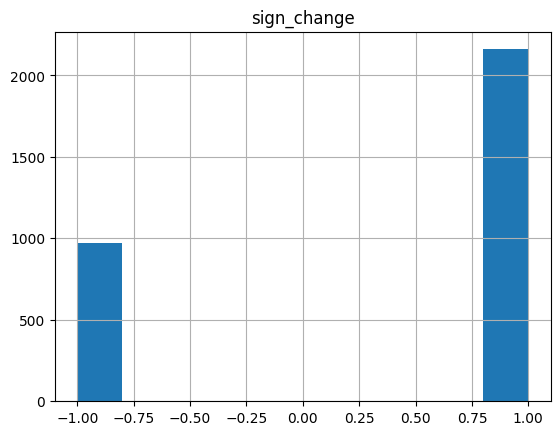

In [ ]:
#see how many news impact both ways from 5 to 30 min (ie, first negative, then positive or the other way). These should be considered as random
news['sign_change']=np.sign(news['ret_5m']*news['ret_30m'])
news['progress']= news['abs_ret_30m']>np.abs(news['ret_5m'])
news[['ret_5m','ret_30m', 'sign_change']].hist('sign_change')

In [ ]:
news['sign_change'].value_counts(normalize=True)

sign_change
 1.0    0.690316
-1.0    0.309684
Name: proportion, dtype: float64

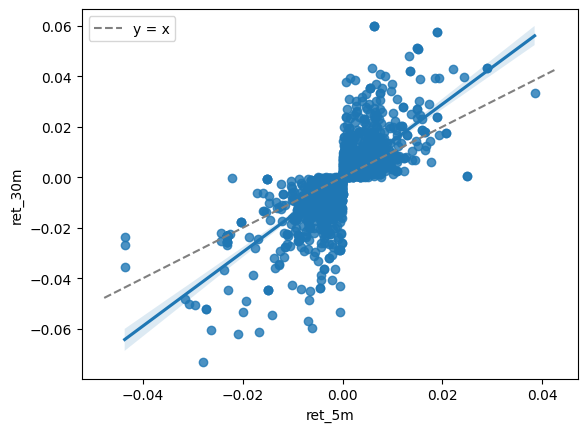

In [ ]:
import seaborn as sns
ax = sns.regplot(
    data=news[news['sign_change'] > 0],
    x='ret_5m',
    y='ret_30m'
)

# y = x reference line
xmin, xmax = ax.get_xlim()
ax.plot([xmin, xmax], [xmin, xmax], linestyle='--', color='gray', label='y = x')

ax.legend()
plt.show()

The plot above shows that a large fraction of the impacts progress in time, meaning that they get more positive or more negative- ie, the impact persists

6419


array([[<Axes: title={'center': 'article_count'}>]], dtype=object)

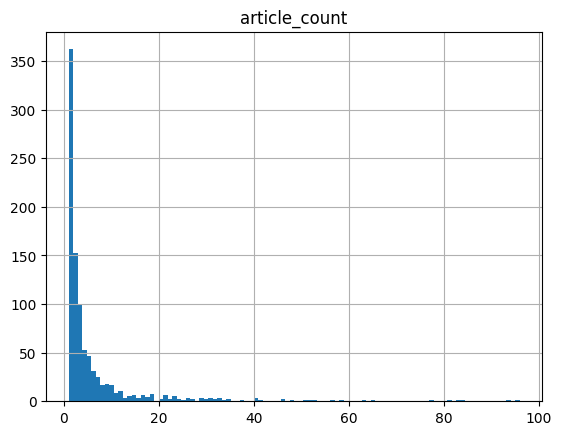

In [ ]:
df = (
    news[['creator', 'article_id']]
    .groupby('creator')
    .size()
    .sort_values()
    .rename('article_count')
    .to_frame()
)
print(df['article_count'].sum())
#out of 6.4k articles, the top three creators are: 
# Temitope Olatunji                    104
# Boluwatife Afe                       105
# Bitcoin Ethereum News                893
# with about 700 articles written by creators that published 3 or less times in the cohort

#print(df.groupby('article_count').size())

df[df['article_count']<100].hist('article_count', bins=100)


<Axes: xlabel='progress'>

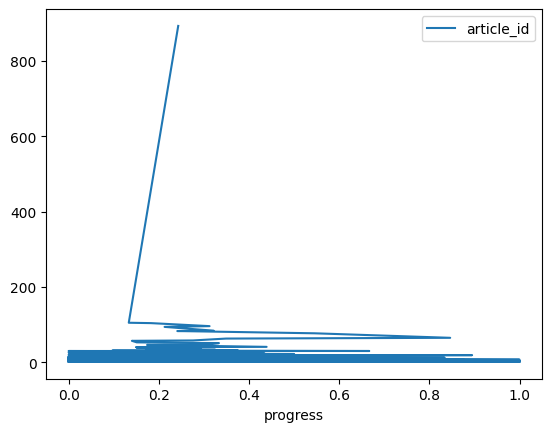

In [ ]:
#lets see if the avg ret per creator is significative
df = news.groupby('creator').agg({'progress': 'mean', 'article_id':'count'}).sort_values(by ='article_id')
df[df['article_id']>2].sort_values(by='progress',ascending=False)
df.plot('progress', 'article_id')

In [ ]:
news_abs.quantile([0.75,0.9, 0.95])

0.75    0.009247
0.90    0.017878
0.95    0.025255
Name: abs_ret_30m, dtype: float64

In [ ]:
news['high_impact'] =((news['abs_ret_30m']>0.009)& (news['sign_change']==1) & (news['progress']==True)).astype(int)
news['high_impact'].value_counts(normalize=True)


high_impact
0    0.811441
1    0.188559
Name: proportion, dtype: float64

In [ ]:
# potential features
# title_word_count, description_word_count, source_id, creator, 'keywords', 'sentiment',tf-idf score for title and description
news['keywords'].isna().value_counts()

keywords
False    2810
True      319
Name: count, dtype: int64